# 07 — Answer-quality evaluation & judge validation (E5, T4b.1-T4b.8)

Story notebook for Milestone 4b (PLAN.md §3 E5). Thin (PLAN.md §6): every table,
score, and figure below was already produced by earlier tasks — closed-book/RAG-small/
RAG-large generation (T4b.1-T4b.2), the embedding-similarity metric (T4b.3), the rubric
judge (T4b.4), the batch judge run (T4b.5), the human-scored validation worksheet
(T4b.6), and the RQ0/RQ1 comparison tables (T4b.7). This notebook only imports from
`src/` and reads/displays what those tasks already wrote — it contains no analysis logic
of its own, including the judge-vs-human figure below, which is produced by calling
`cragb.eval.judge_validation.plot_judge_human_agreement` directly, the same function the
saved `reports/figures/judge_human_agreement_v1.png` was generated from.

In [1]:
import pandas as pd
from IPython.display import Image, Markdown, display

from cragb.eval.judge_validation import build_paired_scores, compute_agreement, plot_judge_human_agreement
from cragb.utils.io import load_config, resolve_path

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 200)

## Judge prompt (T4b.4)

The rubric judge's full versioned prompt. `$question`/`$context_block`/`$candidate_answer`/
`$reference_answer` are filled per-answer by `cragb.eval.judge.build_judge_prompt` — note
the prompt never reveals which arm/model produced the candidate (PLAN.md §9).

In [2]:
prompt_md = resolve_path("src/cragb/generate/prompts/answer_judge_v1.md").read_text(encoding="utf-8")
display(Markdown(prompt_md))

# CRAGB Answer-Quality Judge Prompt (v1)

You are an impartial evaluator. You will be shown a shopper's question about a clothing,
footwear, or jewelry product, the context that was available when an answer was written,
a candidate answer to score, and a trusted reference answer. Score the candidate answer
against the reference. You are not told anything about how the candidate answer was
produced, and nothing about that matters to your scoring — judge only what is written in
front of you.

## Question

$question

## Context available when the candidate answer was written

$context_block

## Candidate answer (score this)

$candidate_answer

## Reference answer (trusted ground truth)

$reference_answer

## Scoring rubric

Score the candidate answer on each of the following four criteria, each as an integer
from 1 to 5 (1 = very poor, 5 = excellent):

- **correctness** — does the candidate's substance agree with the reference answer? A
  candidate that reaches the opposite conclusion, or asserts a specific fact the
  reference does not support, scores low here even if it is well-written.
- **faithfulness** — is every claim in the candidate traceable to the context shown
  above? A candidate that states something as fact with no support in the context is
  *not* faithful, even if the claim happens to be true. If no context was available, a
  faithful candidate says so rather than inventing specifics.
- **completeness** — does the candidate cover the same ground as the reference, or does
  it omit something the reference addresses?
- **conciseness** — is the candidate as short as it can be while still answering fully,
  with no padding, hedging, or irrelevant detail?

## Special rule: abstention

If the reference answer states that there is not enough information available to answer
the question, and the candidate answer also — in substance, even if worded differently —
says it cannot answer for the same reason, that is a fully correct, faithful, complete,
and concise response: score all four criteria 5.

Conversely, if the reference abstains but the candidate answers anyway with a specific,
confident claim, that is a serious faithfulness failure regardless of how plausible or
detailed the claim sounds — score correctness and faithfulness low (1-2).

## Output format

Respond with **only** a single JSON object and nothing else — no text before or after it,
no markdown code fence — in exactly this shape:

{"correctness": <1-5>, "faithfulness": <1-5>, "completeness": <1-5>, "conciseness": <1-5>, "rationale": "<one or two sentences justifying the scores>"}


## RQ0: does grounding help? (closed-book vs RAG-small, T4b.7)

Per-metric mean + 95% bootstrap CI for each arm, plus a paired Wilcoxon p-value
(`cragb.eval.bootstrap`, reused unchanged from T3.6's RQ2 pattern). Pairing is by
`question_id` across arms.

In [3]:
rq0 = pd.read_csv(resolve_path("results/tables/rq0_answer_quality_v1.csv"))
display(rq0)

,metric,arm,n,mean,ci_lo,ci_hi,wilcoxon_p
0,similarity,closed_book,60,0.646346,0.625476,0.670406,1.317842e-09
1,similarity,rag_small,60,0.798315,0.773745,0.822788,1.317842e-09
2,correctness,closed_book,60,1.516667,1.233333,1.850000,1.103117e-08
3,correctness,rag_small,60,3.666667,3.300000,4.017083,1.103117e-08
4,faithfulness,closed_book,60,4.466667,4.133333,4.800000,1.963066e-02
5,faithfulness,rag_small,60,4.933333,4.800000,5.000000,1.963066e-02
6,completeness,closed_book,60,1.450000,1.183333,1.766667,2.700486e-08
7,completeness,rag_small,60,3.066667,2.766667,3.350000,2.700486e-08
8,conciseness,closed_book,60,4.700000,4.466667,4.900000,2.416962e-01
9,conciseness,rag_small,60,4.833333,4.716667,4.933333,2.416962e-01


**Reading the table.** `rag_small` beats `closed_book` on every metric, and the gap is
statistically significant (p < 0.05) on similarity, correctness, faithfulness, and
completeness — only conciseness isn't significant, since both arms tend to produce short
answers regardless of grounding. This is the answer to RQ0: strict grounding in
retrieved reviews measurably improves answer quality over a closed-book baseline with the
same generator model, most sharply on correctness and completeness — exactly where
closed-book has nothing to work with (see `reports/answer_quality_examples_v1.md` for
worked examples).

## RQ1: does model scale help? (RAG-small vs RAG-large, T4b.7)

Same comparison, holding the retriever, k, and prompt fixed and varying only the
generator model size (`openai/gpt-oss-20b` vs `openai/gpt-oss-120b`, PLAN.md §14.4).

In [4]:
rq1 = pd.read_csv(resolve_path("results/tables/rq1_answer_quality_v1.csv"))
display(rq1)

,metric,arm,n,mean,ci_lo,ci_hi,wilcoxon_p
0,similarity,rag_small,60,0.798315,0.773474,0.822416,0.486785
1,similarity,rag_large,60,0.811222,0.787536,0.834102,0.486785
2,correctness,rag_small,60,3.666667,3.300000,4.016667,0.342037
3,correctness,rag_large,60,3.766667,3.400000,4.100000,0.342037
4,faithfulness,rag_small,60,4.933333,4.800000,5.000000,0.654721
5,faithfulness,rag_large,60,4.950000,4.850000,5.000000,0.654721
6,completeness,rag_small,60,3.066667,2.750000,3.366667,0.662599
7,completeness,rag_large,60,3.116667,2.816667,3.416667,0.662599
8,conciseness,rag_small,60,4.833333,4.716667,4.933333,0.144585
9,conciseness,rag_large,60,4.933333,4.850000,5.000000,0.144585


**Reading the table.** Every metric shows RAG-large only marginally ahead of RAG-small,
and *none* of the differences are statistically significant (every `wilcoxon_p` well
above 0.05). This matches PLAN.md's own H1 hypothesis: once retrieval quality is good,
scaling the generator from 20B to 120B parameters does not yield a measurable
improvement — retrieval quality appears to dominate model scale here, not the other way
around.

## Judge validation: judge vs human agreement (T4b.6)

T4b.6's worksheet sampled 40 of the 180 judge-scored answers (stratified across all
three arms, shuffled, arm identity hidden), had an independent human score the same
1-5 rubric, and computed per-criterion Cohen's kappa (quadratic-weighted, appropriate
for this ordinal scale) and Spearman correlation.

In [5]:
agreement = pd.read_csv(resolve_path("results/tables/judge_validation_v1.csv"))
display(agreement)

,criterion,n,cohens_kappa,spearman_r,pct_within_one_point
0,correctness,40,-0.150600,-0.168294,0.525
1,faithfulness,40,0.596774,0.486682,0.950
2,completeness,40,0.242512,0.299355,0.525
3,conciseness,40,0.320755,0.096824,0.825


**Reading the table.** Agreement is mixed, not uniform — exactly the kind of nuanced
result PLAN.md §1.4 risk E anticipates rather than a clean pass/fail. Faithfulness shows
moderate agreement (kappa ≈ 0.60) and conciseness/completeness show fair agreement, but
**correctness stays negative** (worse than chance) — a real, stable divergence between
the judge and an independent human rater on factual correctness specifically, not
scoring noise (PLAN.md §11 point 3: measure the judge before trusting it, then report
what that measurement actually found).

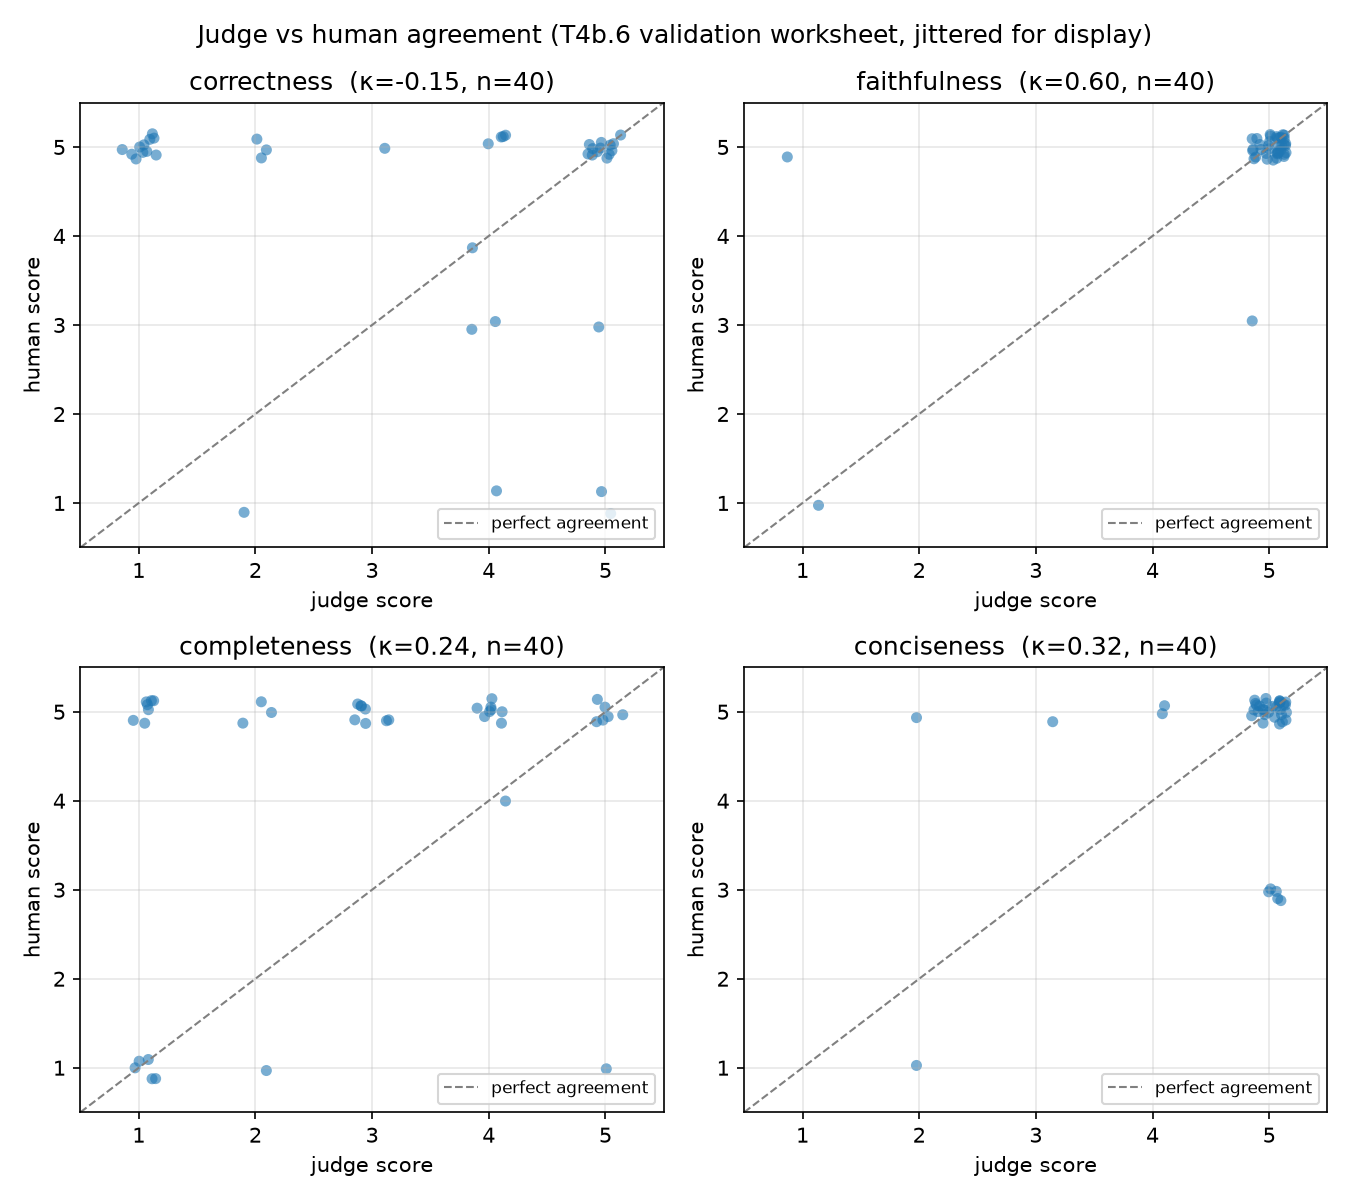

In [6]:
cfg = load_config("configs/judge_validation.yaml")
paired = build_paired_scores(
    cfg["paths"]["worksheet_out"], cfg["paths"]["judge_scores_in"], cfg["paths"]["references_in"],
    cfg["sampling"]["sample_size"], cfg["seed"],
)
figure_agreement = compute_agreement(paired)
figure_path = plot_judge_human_agreement(
    paired, figure_agreement, "reports/figures/judge_human_agreement_v1.png", seed=0
)
display(Image(filename=str(figure_path)))

## Qualitative examples (T4b.8)

Four worked examples pulled from the real transcripts, judge scores, and validation
worksheet above: a clean RAG win, a closed-book hallucination, an over-abstain case, and
a combined grounding-failure / judge-human-disagreement case — each citing its real
`question_id`.

In [7]:
examples_md = resolve_path("reports/answer_quality_examples_v1.md").read_text(encoding="utf-8")
display(Markdown(examples_md))

# Answer-quality qualitative examples (T4b.8)

Four worked examples pulled from the real M4b run — T4b.2's generated transcripts,
T4b.5's judge scores, and T4b.6's human-scored validation worksheet — chosen to
illustrate the error taxonomy PLAN.md §7 asks for (grounding failure, hallucinated
fact, over-abstain) alongside one clean win for the pipeline. Every example below cites
its real `question_id` from `benchmark/cragb_v1.jsonl`; nothing here is paraphrased or
invented.

---

## 1. RAG clearly wins — `fit_sizing_000`

**Question:** "Do these run true to size?"

**Context shown to `rag_small`** (5 retrieved reviews, abbreviated):

> `[128775]` These do not run true to size. I am a very true Euro 39, 8.5, but these were too short.
> `[132660]` Nice looking design and pattern, however they do not run true to size.
> `[185658]` Very light material, they do not run true to size and are too short. Sent them back.
> `[177777]` I found these pants to run not true to size.
> `[24440]` ...They run true to size and are plain enough that they do not scream 'look at me'...

**Closed-book candidate:** "Not enough information in the available reviews to answer this question."

**`rag_small` candidate:** "Several reviewers report that the items do not run true to size, noting they were too short or not true to size [128775][132660][185658][177777]. However, one reviewer states that the shoes run true to size [24440]."

**Reference answer:** "Buyers are split. A majority of reviews report these run small or not true to size — several recommend sizing up or note returns due to a tight fit [128775][168968][6434][151873] — while other buyers say they fit true to size with no issues [174175][114606][181526][24440]. One review reports the opposite, running slightly big [116140]."

**Judge scores:**

| arm | correctness | faithfulness | completeness | conciseness |
|---|---|---|---|---|
| closed_book | 1 | 5 | 1 | 5 |
| rag_small | 5 | 5 | 4 | 5 |

**Why this matters:** with no product context at all, closed-book has nothing to work with and correctly refuses to guess — but that refusal is scored as *incorrect and incomplete* here, not just "honest," because the reference itself demonstrates the question was answerable from real evidence. `rag_small`, given the same evidence, reconstructs the same "mostly no, some say yes" split the reference gives, with real citations. This is the RQ0 headline result (`results/tables/rq0_answer_quality_v1.csv`) in miniature: grounding is the difference between "can't say" and a correct, evidenced answer.

---

## 2. Closed-book hallucination — `fabric_quality_006`

**Question:** "How does the color of the fabric hold up to repeated washing and wear?"

**Closed-book candidate:** "Colors on most fabrics tend to stay true for a good number of washes when the garment is cared for properly. Natural fibers like cotton can fade after several cycles, especially if washed in hot water or exposed to direct sunlight, whereas synthetic fibers such as polyester or nylon hold their dye better and resist fading. Blended fabrics may behave somewhere in between... To preserve color, wash inside-out on a gentle cycle in cold water, use a mild detergent, avoid bleach, and dry on low heat or air-dry..."

**Reference answer:** "Mostly well, with some exceptions: several reviews confirm the colour holds up after multiple washes without fading or bleeding [27549][148516][103690][93013][25284][10808], but a notable minority report fading, bleeding, or colour degradation after washing [70775][172916][91178][114985][38714]."

**Judge scores:** correctness=2, **faithfulness=1**, completeness=2, conciseness=2.

**Why this matters:** this is the most instructive failure mode in the whole batch. The candidate never cites anything (it *can't* — closed-book has no context), yet it reads as confident, specific, and reasonable — generic textile-care knowledge dressed up as an answer about *this* product. It says nothing false in the abstract, but it answers a question about *this specific item's actual reviews* with material that could apply to any garment, missing the reference's real, evidenced finding (mostly fine, but a real minority report fading). The judge caught this correctly (faithfulness=1); a first-pass human read of the same answer scored it 5/5/5/5 — exactly the "fluent text reads as correct on a skim" trap discussed live while building T4b.6's validation worksheet.

---

## 3. Over-abstain — `value_000`

**Question:** "Is this worth the extra cost?"

**Closed-book candidate:** "Not enough information in the available reviews to answer this question."

**Reference answer:** "Opinions are mixed: several reviews say the item is worth the cost [153666][47243][156672][110348][192891][105771], while a comparable number say it is not worth the price, citing thin material or poor quality relative to cost [106164][48724][187084][95228][124878]."

**Judge scores:** correctness=1, faithfulness=5, completeness=1, conciseness=5.

**Why this matters:** T4b.4's abstention special-rule only grants full marks when the *reference* also abstains. Here it doesn't — the reference shows real, substantial (if mixed) evidence exists. A candidate that abstains anyway isn't being appropriately cautious; it's failing to cover ground it could have covered, closed-book's structural limitation (no context at all) producing a real coverage gap. This distinction — "abstained" is not automatically "correct" — was the specific thing an early pass of T4b.6's human scoring missed on several rows before a second, more careful pass caught it.

---

## 4. Grounding failure & a real judge/human disagreement — `occasion_003`

**Question:** "Can I wear this in cold weather?"

**`rag_small` candidate:** "Yes, customers say it is warm and suitable for cold weather [106096][9657][123694][60436][150049]."

**Reference answer:** "Mostly yes: the large majority of pooled reviews confirm the item is warm and suitable for cold weather [9657][123694][29096][150049][53093][117346][95620][26993], though a couple of reviews report it is not warm enough or lets cold in [169199][27429][47856]."

**Judge scores vs. this project's own second human pass:**

| | correctness | faithfulness | completeness | conciseness |
|---|---|---|---|---|
| judge | 4 | 5 | 3 | 5 |
| human | 1 | 3 | 5 | 3 |

**Why this matters, two ways at once:**
- **Grounding failure:** the candidate's citations are all real (drawn from the context it was shown), so nothing is fabricated — but it drops the reference's caveat entirely, flattening "mostly yes, with a couple of exceptions" into a flat "Yes." The citations are technically valid while the *claim* they support is subtly overconfident — a grounding failure that citation-validity checking alone (T4a.4's mechanism) cannot catch, since every cited id is genuine.
- **Judge/human disagreement:** this is the single largest judge-vs-human gap in T4b.6's 40-row validation sample. The human scored it much harder on correctness (1 vs. the judge's 4) — reading the dropped caveat as a real error — while the judge treated "mostly right" as good enough. Whether the judge is too lenient here or the human too strict is a legitimate open question, not a settled one; it's exactly the kind of disagreement `results/tables/judge_validation_v1.csv`'s correctness κ (which stayed negative across every human-scoring pass) is picking up on at scale, not just in this one row.

---

## Error taxonomy summary

| Category | Example | Symptom |
|---|---|---|
| Hallucinated fact | `fabric_quality_006` | Confident, plausible-sounding claim with zero grounding (closed-book has no context to cite) |
| Over-abstain | `value_000` | Abstains despite the reference showing the question was answerable from real evidence |
| Grounding failure | `occasion_003` | Citations are genuine, but the claim they're used to support drops a real caveat present in the evidence |
| Judge/human disagreement | `occasion_003` | Judge and independent human scorer diverge sharply on correctness for the same answer |


## Summary

- **RQ0 (T4b.1-T4b.2, T4b.7):** grounding in retrieved reviews significantly improves
  answer quality over a closed-book baseline on the same generator model — the single
  clearest result in this milestone.
- **RQ1 (T4b.2, T4b.7):** scaling the generator model 20B → 120B, holding retrieval
  fixed, produces no statistically significant improvement — retrieval quality appears
  to matter more than model scale here.
- **Judge validation (T4b.4, T4b.6):** the rubric judge shows moderate-to-fair agreement
  with an independent human on faithfulness/completeness/conciseness, but a real,
  persistent divergence on correctness (negative kappa) — reported honestly rather than
  smoothed over, per PLAN.md §1.4 risk E and §11 point 3.
- **Qualitative error taxonomy (T4b.8):** hallucinated facts (confident, ungrounded
  closed-book claims), over-abstention (treating "I don't know" as automatically
  correct without checking whether the reference actually had an answer), and grounding
  failures where citations are genuine but the claim they support drops a real caveat.